# COSMIC sample visualizer

修改下一格中的 `QUESTION_TYPE` 和 `IMG_ID`，然后运行全部单元格。角色划分与 `main.py` 保持一致：拥有非空问题的用户是 answerer，另一位是 helper。

In [13]:
QUESTION_TYPE = "relative_distance"
IMG_ID = 3

DATA_ROOT = "data"
PARQUET_NAME = "test-00000.parquet"

In [14]:
from io import BytesIO
from pathlib import Path
from html import escape

import matplotlib.pyplot as plt
import pyarrow.parquet as pq
from IPython.display import HTML, display
from PIL import Image


def load_image(image_data):
    """Load an image stored as parquet bytes/path, raw bytes, or a PIL image."""
    if isinstance(image_data, Image.Image):
        return image_data

    if isinstance(image_data, dict):
        if image_data.get("bytes") is not None:
            return Image.open(BytesIO(image_data["bytes"])).convert("RGB")
        if image_data.get("path"):
            return Image.open(image_data["path"]).convert("RGB")

    if isinstance(image_data, (bytes, bytearray)):
        return Image.open(BytesIO(image_data)).convert("RGB")

    if isinstance(image_data, (str, Path)):
        return Image.open(image_data).convert("RGB")

    raise ValueError("Unsupported or empty image data")


def get_sample(question_type, img_id):
    parquet_path = Path(DATA_ROOT) / question_type / PARQUET_NAME
    if not parquet_path.exists():
        available = sorted(path.name for path in Path(DATA_ROOT).iterdir() if path.is_dir())
        raise FileNotFoundError(
            f"Dataset not found: {parquet_path}. Available QUESTION_TYPE values: {available}"
        )

    table = pq.read_table(parquet_path)
    if not 0 <= img_id < table.num_rows:
        raise IndexError(f"IMG_ID must be between 0 and {table.num_rows - 1}, got {img_id}")

    return {column: table[column][img_id].as_py() for column in table.column_names}


def split_answerer_helper(qa):
    """Mirror the answerer/helper assignment in main.py."""
    if qa["user_1_question"] is None:
        answerer_id, helper_id = 2, 1
    else:
        answerer_id, helper_id = 1, 2

    return {
        "answerer_id": answerer_id,
        "helper_id": helper_id,
        "answerer_image": qa[f"user_{answerer_id}_image"],
        "helper_image": qa[f"user_{helper_id}_image"],
        "question": qa[f"user_{answerer_id}_question"],
        "options": qa[f"options_user_{answerer_id}"],
        "gt_idx": qa[f"user_{answerer_id}_gt_answer_idx"],
        "gt_text": qa[f"user_{answerer_id}_gt_answer_text"],
    }


def display_images(qa, roles):
    images = [
        (f"Answerer (user {roles['answerer_id']})", roles["answerer_image"]),
        (f"Helper (user {roles['helper_id']})", roles["helper_image"]),
    ]

    if qa.get("global_map_image") is not None:
        images.append(("Map (Answerer only)", qa["global_map_image"]))

    figure, axes = plt.subplots(1, len(images), figsize=(7 * len(images), 6))
    if len(images) == 1:
        axes = [axes]

    for axis, (title, image_data) in zip(axes, images):
        axis.imshow(load_image(image_data))
        axis.set_title(title, fontsize=15, fontweight="bold")
        axis.axis("off")

    plt.tight_layout()
    plt.show()


def display_question(qa, roles):
    labels = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"
    options = roles["options"] or []
    gt_idx = None if roles["gt_idx"] is None else int(roles["gt_idx"])
    gt_label = labels[gt_idx] if gt_idx is not None and gt_idx < len(labels) else "?"

    option_rows = "".join(
        f"<div style='padding:8px 12px; margin:5px 0; border-radius:6px; "
        f"background:{'#e8f5e9' if index == gt_idx else '#f5f5f5'};'>"
        f"<b>{labels[index]}.</b> {escape(str(option))}</div>"
        for index, option in enumerate(options)
    )

    metadata = (
        f"<b>QUESTION_TYPE:</b> {escape(str(QUESTION_TYPE))} &nbsp; | &nbsp; "
        f"<b>IMG_ID:</b> {IMG_ID} &nbsp; | &nbsp; "
        f"<b>sample_id:</b> {escape(str(qa.get('sample_id', 'N/A')))} &nbsp; | &nbsp; "
        f"<b>scene_id:</b> {escape(str(qa.get('scene_id', 'N/A')))}"
    )

    html = f"""
    <div style="font-family:Arial,sans-serif; font-size:16px; line-height:1.5; max-width:1200px;">
      <div style="color:#555; margin-bottom:14px;">{metadata}</div>
      <h3 style="margin-bottom:6px;">Question</h3>
      <div style="padding:12px; background:#eef4ff; border-radius:6px;">
        {escape(str(roles['question']))}
      </div>
      <h3 style="margin-bottom:6px;">Options</h3>
      {option_rows}
      <h3 style="margin-bottom:6px;">Ground Truth</h3>
      <div style="padding:12px; background:#e8f5e9; border-left:5px solid #43a047; border-radius:4px;">
        <b>{gt_label}.</b> {escape(str(roles['gt_text']))}
      </div>
    </div>
    """
    display(HTML(html))


def visualize_sample(question_type, img_id):
    qa = get_sample(question_type, img_id)
    roles = split_answerer_helper(qa)
    display_images(qa, roles)
    display_question(qa, roles)
    return qa


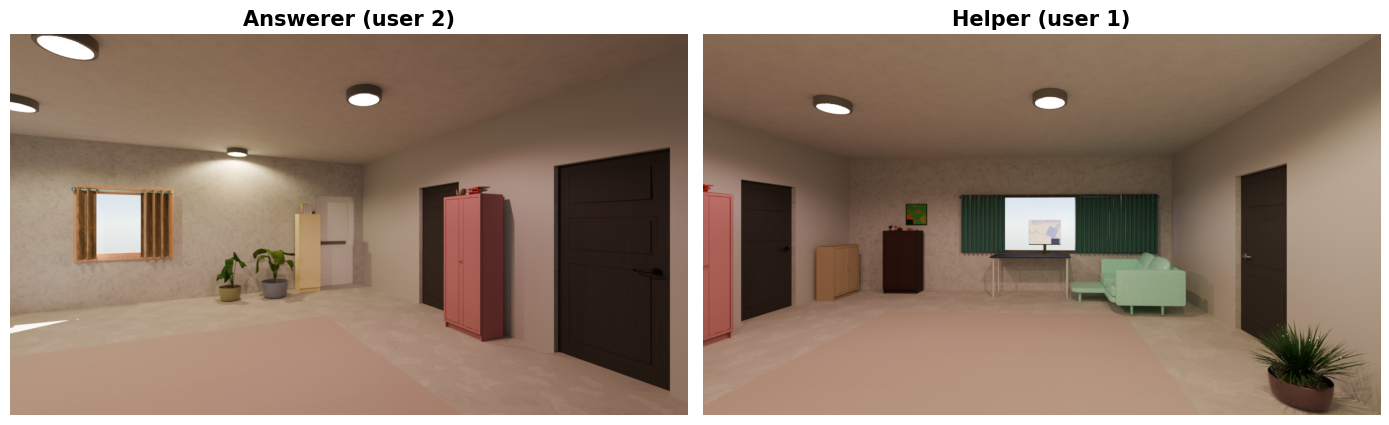

In [15]:
qa = visualize_sample(QUESTION_TYPE, IMG_ID)